In [1]:
import pandas as pd

df = pd.read_csv("audible_books.csv")

df.head()

,title,author,price,rating_raw,length_raw
0,The Social Media Marketing Blueprint,Mark Hrvatin,$5.99or free with 30-day trial,4.52 ratings,Length: 3 hrs and 39 mins
1,The Book,Keith Houston,$20.56or free with 30-day trial,4.526 ratings,Length: 9 hrs and 58 mins
2,"CIA MIND SCIENCE, CODES & CIPHERS",Eric Engle,$14.99or free with 30-day trial,3.48 ratings,Length: 6 hrs and 19 mins
3,I Am a Strange Loop,Douglas R Hofstadter,$35.09or free with 30-day trial,4.2417 ratings,Length: 16 hrs and 47 mins
4,The Art of Game Design (3rd Edition),Jesse Schell,$32.20or free with 30-day trial,Not rated yet,Length: 22 hrs and 45 mins


In [2]:
# Data Cleaning

# Rating
df["rating"] = df["rating_raw"].str.extract(r"(\d+\.\d+)")
df["rating"] = df["rating"].astype(float)

# Reviews
df["reviews"] = df["rating_raw"].str.extract(r",(\d+)\s+ratings")
df["reviews"] = df["reviews"].astype(float)

# Price
df["price"] = df["price"].str.extract(r"(\d+\.\d+)").astype(float)

# Length
df["hours"] = df["length_raw"].str.extract(r"(\d+)\s+hrs").astype(float)
df["minutes"] = df["length_raw"].str.extract(r"(\d+)\s+mins").astype(float)

df["total_minutes"] = df["hours"] * 60 + df["minutes"]



In [3]:
df.head()

,title,author,price,rating_raw,length_raw,rating,reviews,hours,minutes,total_minutes
0,The Social Media Marketing Blueprint,Mark Hrvatin,5.99,4.52 ratings,Length: 3 hrs and 39 mins,4.5200,NaN,3.0,39.0,219.0
1,The Book,Keith Houston,20.56,4.526 ratings,Length: 9 hrs and 58 mins,4.5260,NaN,9.0,58.0,598.0
2,"CIA MIND SCIENCE, CODES & CIPHERS",Eric Engle,14.99,3.48 ratings,Length: 6 hrs and 19 mins,3.4800,NaN,6.0,19.0,379.0
3,I Am a Strange Loop,Douglas R Hofstadter,35.09,4.2417 ratings,Length: 16 hrs and 47 mins,4.2417,NaN,16.0,47.0,1007.0
4,The Art of Game Design (3rd Edition),Jesse Schell,32.20,Not rated yet,Length: 22 hrs and 45 mins,NaN,NaN,22.0,45.0,1365.0


In [4]:
# Droping unnecessary columns
df = df.drop(columns=["rating_raw", "length_raw", "hours", "minutes"])

In [6]:
df.head()

,title,author,price,rating,reviews,total_minutes
0,The Social Media Marketing Blueprint,Mark Hrvatin,5.99,4.5200,NaN,219.0
1,The Book,Keith Houston,20.56,4.5260,NaN,598.0
2,"CIA MIND SCIENCE, CODES & CIPHERS",Eric Engle,14.99,3.4800,NaN,379.0
3,I Am a Strange Loop,Douglas R Hofstadter,35.09,4.2417,NaN,1007.0
4,The Art of Game Design (3rd Edition),Jesse Schell,32.20,NaN,NaN,1365.0


In [7]:
# More cleaning
df["rating"] = df["rating"].round(1)

df["rating"] = df["rating"].fillna(0)
df["reviews"] = df["reviews"].fillna(0)
df["total_minutes"] = df["total_minutes"].fillna(0)

df["reviews"] = df["reviews"].astype(int)
df["total_minutes"] = df["total_minutes"].astype(int)

df["rating"] = df["rating"].astype(float)

In [8]:
df.head()

,title,author,price,rating,reviews,total_minutes
0,The Social Media Marketing Blueprint,Mark Hrvatin,5.99,4.5,0,219
1,The Book,Keith Houston,20.56,4.5,0,598
2,"CIA MIND SCIENCE, CODES & CIPHERS",Eric Engle,14.99,3.5,0,379
3,I Am a Strange Loop,Douglas R Hofstadter,35.09,4.2,0,1007
4,The Art of Game Design (3rd Edition),Jesse Schell,32.20,0.0,0,1365


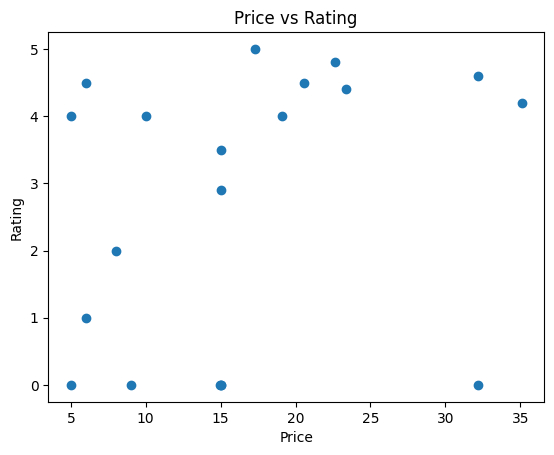

In [12]:
# Analysis Questions:
# Do higher-priced books have better ratings? Is expensive = better?
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["price"], df["rating"])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()




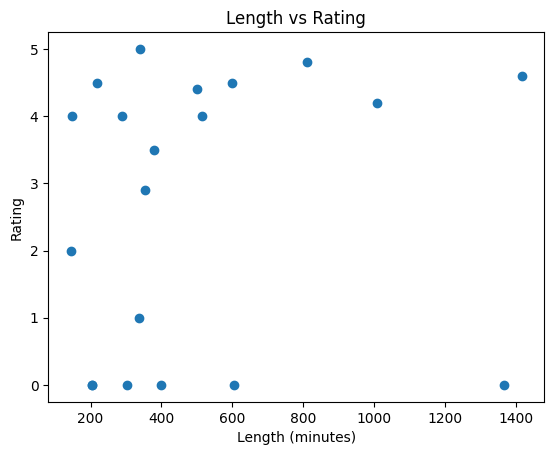

In [13]:
# Do longer audiobooks get higher ratings?
plt.figure()
plt.scatter(df["total_minutes"], df["rating"])
plt.xlabel("Length (minutes)")
plt.ylabel("Rating")
plt.title("Length vs Rating")
plt.show()

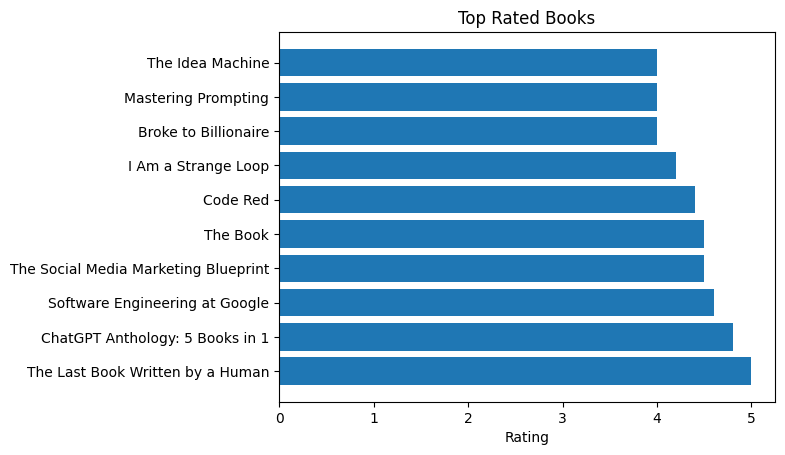

In [14]:
# What are the top-rated books?
top_rated = df.sort_values(by="rating", ascending=False).head(10)

plt.figure()
plt.barh(top_rated["title"], top_rated["rating"])
plt.xlabel("Rating")
plt.title("Top Rated Books")
plt.show()